In [1]:
import torch

print("=" * 80)
print("GPU CHECK")
print("=" * 80)

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print("CUDA version    :", torch.version.cuda)
    print("GPU count       :", torch.cuda.device_count())
else:
    print("WARNING: CUDA GPU is not available.")

print("=" * 80)

GPU CHECK
PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : Tesla T4
CUDA version    : 12.8
GPU count       : 2


In [2]:
import os
import sys
import json
import math
import time
import random
import shutil
import zipfile
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler

from torchvision import datasets, transforms
from torchvision.models import vgg19, VGG19_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    log_loss,
    cohen_kappa_score,
    matthews_corrcoef,
    brier_score_loss
)

from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

print("All imports successful.")

All imports successful.


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)

Random seed: 42


In [4]:
# ============================================================
# VGG19 — DDR CONFIGURATION
# ============================================================

IMAGE_SIZE = 224

BATCH_SIZE = 16

EPOCHS = 50

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 5e-4

NUM_CLASSES = 5

NUM_WORKERS = 2

EARLY_STOPPING_PATIENCE = 100

LR_PATIENCE = 3

LR_FACTOR = 0.5

MIN_LR = 1e-7

MODEL_NAME = "VGG19"

CLASS_NAMES = ["0_No_DR", "1_Mild", "2_Moderate", "3_Severe", "4_Proliferative_DR"]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("VGG19 — DDR CONFIGURATION")
print("=" * 80)

print("Model            :", MODEL_NAME)
print("Dataset          : DDR")
print("Image size       :", IMAGE_SIZE)
print("Batch size       :", BATCH_SIZE)
print("Epochs           :", EPOCHS)
print("Learning rate    :", LEARNING_RATE)
print("Weight decay     :", WEIGHT_DECAY)
print("Number of classes:", NUM_CLASSES)
print("Workers          :", NUM_WORKERS)
print("Device           :", DEVICE)

print("=" * 80)

VGG19 — DDR CONFIGURATION
Model            : VGG19
Dataset          : DDR
Image size       : 224
Batch size       : 16
Epochs           : 50
Learning rate    : 0.0001
Weight decay     : 0.0005
Number of classes: 5
Workers          : 2
Device           : cuda


In [5]:
KAGGLE_INPUT = Path("/kaggle/input")

print("=" * 80)
print("KAGGLE INPUT DATASETS")
print("=" * 80)

for item in KAGGLE_INPUT.iterdir():
    print(item)

KAGGLE INPUT DATASETS
/kaggle/input/datasets


In [6]:
def find_ddr_dataset_root(base_dir="/kaggle/input"):

    base_dir = Path(base_dir)

    candidates = []

    for train_path in base_dir.rglob("train"):

        if not train_path.is_dir():
            continue

        parent = train_path.parent

        if (
            (parent / "val").is_dir()
            and (parent / "test").is_dir()
        ):
            candidates.append(parent)

    if len(candidates) == 0:

        raise FileNotFoundError(
            "Could not automatically locate DDR "
            "train/val/test folders."
        )

    print("Candidate dataset roots:")

    for c in candidates:
        print(" -", c)

    return candidates[0]


DATASET_ROOT = find_ddr_dataset_root()

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

print("\nSelected DDR root:")
print(DATASET_ROOT)

print("\nTrain:")
print(TRAIN_DIR)

print("\nValidation:")
print(VAL_DIR)

print("\nTest:")
print(TEST_DIR)

Candidate dataset roots:
 - /kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr

Selected DDR root:
/kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr

Train:
/kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr/train

Validation:
/kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr/val

Test:
/kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr/test


In [7]:
print("=" * 80)
print("DDR DATASET STRUCTURE")
print("=" * 80)

for split_name, split_dir in [
    ("TRAIN", TRAIN_DIR),
    ("VAL", VAL_DIR),
    ("TEST", TEST_DIR)
]:

    print(f"\n{split_name}")
    print("-" * 50)

    if not split_dir.exists():

        print("MISSING:", split_dir)
        continue

    for class_dir in sorted(
        split_dir.iterdir()
    ):

        if class_dir.is_dir():

            count = len([
                f
                for f in class_dir.iterdir()
                if f.is_file()
            ])

            print(
                f"{class_dir.name:25s}: {count}"
            )

DDR DATASET STRUCTURE

TRAIN
--------------------------------------------------
0_No_DR                  : 4933
1_Mild                   : 504
2_Moderate               : 3581
3_Severe                 : 189
4_Proliferative_DR       : 730

VAL
--------------------------------------------------
0_No_DR                  : 616
1_Mild                   : 63
2_Moderate               : 448
3_Severe                 : 24
4_Proliferative_DR       : 91

TEST
--------------------------------------------------
0_No_DR                  : 617
1_Mild                   : 63
2_Moderate               : 448
3_Severe                 : 23
4_Proliferative_DR       : 92


In [8]:
def count_images(split_dir):

    counts = {}

    for class_name in CLASS_NAMES:

        class_dir = split_dir / class_name

        if class_dir.exists():

            counts[class_name] = len([
                f
                for f in class_dir.iterdir()
                if f.is_file()
            ])

        else:

            counts[class_name] = 0

    return counts


train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("=" * 80)
print("DDR CLASS COUNTS")
print("=" * 80)

print("\nTRAIN")
for k, v in train_counts.items():
    print(f"{k:25s}: {v}")

print("\nVALIDATION")
for k, v in val_counts.items():
    print(f"{k:25s}: {v}")

print("\nTEST")
for k, v in test_counts.items():
    print(f"{k:25s}: {v}")

DDR CLASS COUNTS

TRAIN
0_No_DR                  : 4933
1_Mild                   : 504
2_Moderate               : 3581
3_Severe                 : 189
4_Proliferative_DR       : 730

VALIDATION
0_No_DR                  : 616
1_Mild                   : 63
2_Moderate               : 448
3_Severe                 : 24
4_Proliferative_DR       : 91

TEST
0_No_DR                  : 617
1_Mild                   : 63
2_Moderate               : 448
3_Severe                 : 23
4_Proliferative_DR       : 92


In [9]:
train_total = sum(train_counts.values())
val_total = sum(val_counts.values())
test_total = sum(test_counts.values())

total_images = (
    train_total +
    val_total +
    test_total
)

print("=" * 80)
print("TOTAL DDR DATASET")
print("=" * 80)

print("Train :", train_total)
print("Val   :", val_total)
print("Test  :", test_total)
print("Total :", total_images)

TOTAL DDR DATASET
Train : 9937
Val   : 1242
Test  : 1243
Total : 12422


In [10]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

print("Mean:", IMAGENET_MEAN)
print("Std :", IMAGENET_STD)

Mean: [0.485, 0.456, 0.406]
Std : [0.229, 0.224, 0.225]


In [11]:
train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomRotation(
        degrees=40
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.20, 0.20),
        shear=0.20,
        scale=(0.80, 1.20)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Training transform created.")

Training transform created.


In [12]:
eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Evaluation transform created.")

Evaluation transform created.


In [13]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)

print("=" * 80)
print("DATASETS CREATED")
print("=" * 80)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

print("\nClass mapping:")
print(train_dataset.class_to_idx)

DATASETS CREATED
Train: 9937
Val  : 1242
Test : 1243

Class mapping:
{'0_No_DR': 0, '1_Mild': 1, '2_Moderate': 2, '3_Severe': 3, '4_Proliferative_DR': 4}


In [14]:
print(
    train_dataset.class_to_idx
)

print(
    "\nOrdered classes:"
)

for idx, name in enumerate(
    train_dataset.classes
):

    print(
        idx,
        "→",
        name
    )

{'0_No_DR': 0, '1_Mild': 1, '2_Moderate': 2, '3_Severe': 3, '4_Proliferative_DR': 4}

Ordered classes:
0 → 0_No_DR
1 → 1_Mild
2 → 2_Moderate
3 → 3_Severe
4 → 4_Proliferative_DR


In [15]:
assert len(train_dataset) == train_total

assert len(val_dataset) == val_total

assert len(test_dataset) == test_total

print("Dataset lengths verified successfully.")

Dataset lengths verified successfully.


In [16]:
assert len(train_dataset) == train_total

assert len(val_dataset) == val_total

assert len(test_dataset) == test_total

print("Dataset lengths verified successfully.")

Dataset lengths verified successfully.


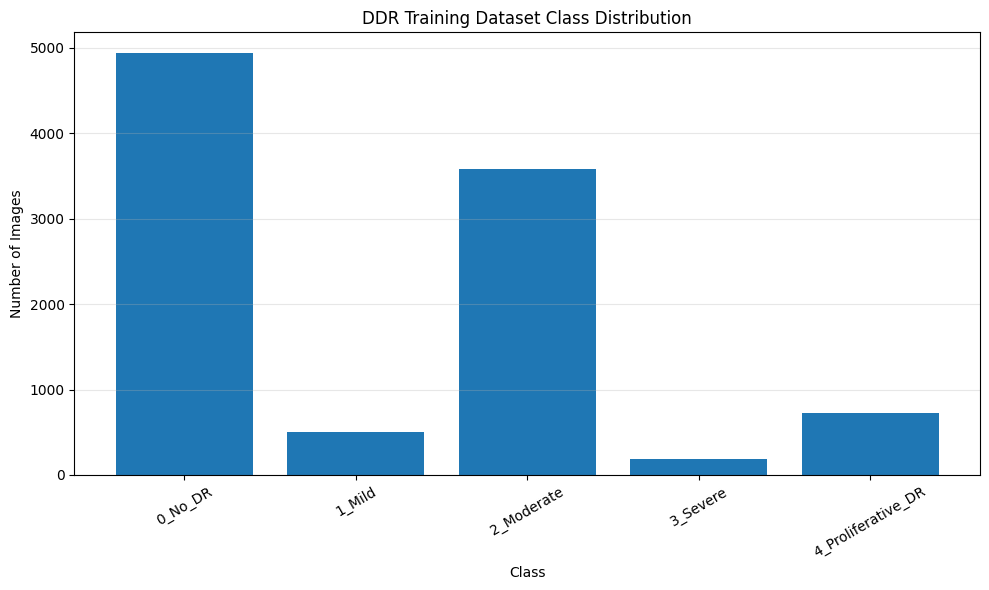

In [17]:
# Extract the counts from your dictionary and convert to a numpy array
class_counts = np.array(list(train_counts.values()))

plt.figure(figsize=(10, 6))
plt.bar(train_dataset.classes, class_counts)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("DDR Training Dataset Class Distribution")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
class_weights = (
    1.0 /
    class_counts
)

sample_weights = np.array([

    class_weights[label]

    for label in train_dataset.targets

])

sample_weights = torch.DoubleTensor(
    sample_weights
)

sampler = WeightedRandomSampler(

    weights=sample_weights,

    num_samples=len(
        sample_weights
    ),

    replacement=True
)

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights)

Class counts:
[4933  504 3581  189  730]

Class weights:
[0.00020272 0.00198413 0.00027925 0.00529101 0.00136986]


In [19]:
train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    sampler=sampler,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=(
        NUM_WORKERS > 0
    )
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=(
        NUM_WORKERS > 0
    )
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=(
        NUM_WORKERS > 0
    )
)

print("DataLoaders created.")

print("\nTrain batches:",
      len(train_loader))

print("Val batches:",
      len(val_loader))

print("Test batches:",
      len(test_loader))

DataLoaders created.

Train batches: 622
Val batches: 78
Test batches: 78


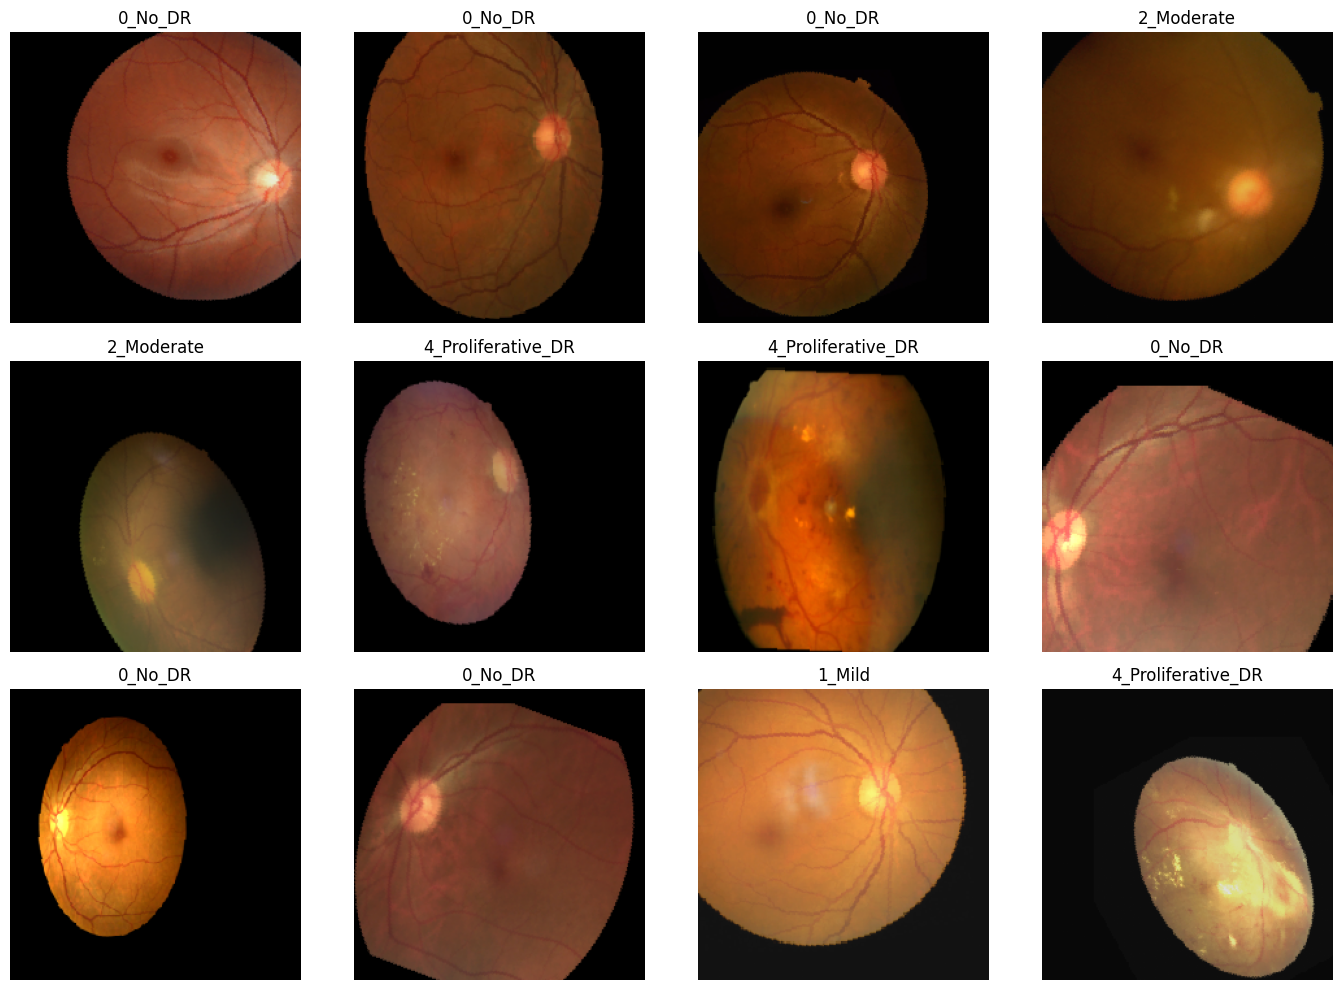

In [20]:
def denormalize(img):

    mean = torch.tensor(
        IMAGENET_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD
    ).view(3, 1, 1)

    img = (
        img.cpu() * std
    ) + mean

    return torch.clamp(
        img,
        0,
        1
    )


images, labels = next(
    iter(train_loader)
)

plt.figure(
    figsize=(14, 10)
)

for i in range(
    min(12, len(images))
):

    plt.subplot(
        3,
        4,
        i + 1
    )

    img = denormalize(
        images[i]
    )

    img = img.permute(
        1,
        2,
        0
    )

    plt.imshow(img)

    label_idx = labels[i].item()

    plt.title(
        train_dataset.classes[
            label_idx
        ]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [21]:
print("=" * 80)
print("BUILDING VGG19")
print("=" * 80)

weights = (
    VGG19_Weights.IMAGENET1K_V1
)

model = vgg19(
    weights=weights
)

print(
    "Original classifier:"
)

print(
    model.classifier
)

# Number of input features
in_features = (
    model.classifier[6]
    .in_features
)

# Replace ImageNet 1000-class output
model.classifier[6] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(
    DEVICE
)

print("\nModified classifier:")

print(
    model.classifier
)

BUILDING VGG19
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 209MB/s]


Original classifier:
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

Modified classifier:
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=5, bias=True)
)


In [22]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 80)
print("VGG19 PARAMETERS")
print("=" * 80)

print(
    f"Total parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_params:,}"
)

VGG19 PARAMETERS
Total parameters     : 139,590,725
Trainable parameters : 139,590,725


In [23]:
criterion = nn.CrossEntropyLoss()

print(
    "Loss function:",
    criterion
)

Loss function: CrossEntropyLoss()


In [24]:
optimizer = optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0005
)


In [25]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=LR_FACTOR,

    patience=LR_PATIENCE,

    min_lr=MIN_LR
)

print(
    "Scheduler created."
)

Scheduler created.


In [26]:
def calculate_metrics(
    y_true,
    y_pred
):

    metrics = {}

    metrics["accuracy"] = (
        accuracy_score(
            y_true,
            y_pred
        )
    )

    metrics["precision_macro"] = (
        precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    metrics["recall_macro"] = (
        recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    metrics["f1_macro"] = (
        f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    metrics["precision_weighted"] = (
        precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )

    metrics["recall_weighted"] = (
        recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )

    metrics["f1_weighted"] = (
        f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )

    metrics["balanced_accuracy"] = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )

    metrics["kappa"] = (
        cohen_kappa_score(
            y_true,
            y_pred
        )
    )

    metrics["mcc"] = (
        matthews_corrcoef(
            y_true,
            y_pred
        )
    )

    return metrics

In [27]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = (
            outputs.argmax(
                dim=1
            )
        )

        all_preds.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )

        all_labels.extend(
            labels.detach()
            .cpu()
            .numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    metrics = calculate_metrics(
        np.array(all_labels),
        np.array(all_preds)
    )

    return (
        epoch_loss,
        metrics
    )

In [28]:
@torch.no_grad()
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_probs = []
    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = probabilities.argmax(
            dim=1
        )

        running_loss += (
            loss.item() *
            images.size(0)
        )

        all_probs.append(
            probabilities
            .cpu()
            .numpy()
        )

        all_preds.extend(
            predictions
            .cpu()
            .numpy()
        )

        all_labels.extend(
            labels
            .cpu()
            .numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    all_probs = np.concatenate(
        all_probs,
        axis=0
    )

    all_preds = np.array(
        all_preds
    )

    all_labels = np.array(
        all_labels
    )

    metrics = calculate_metrics(
        all_labels,
        all_preds
    )

    return (
        epoch_loss,
        metrics,
        all_labels,
        all_preds,
        all_probs
    )

In [29]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_accuracy": [],
    "val_accuracy": [],

    "train_precision_macro": [],
    "val_precision_macro": [],

    "train_recall_macro": [],
    "val_recall_macro": [],

    "train_f1_macro": [],
    "val_f1_macro": [],

    "learning_rate": []

}

print("History initialized.")

History initialized.


In [30]:
OUTPUT_DIR = Path(
    "/kaggle/working/vgg19_ddr_results"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_PATH = (
    OUTPUT_DIR /
    "best_vgg19_ddr.pth"
)

print(
    "Output directory:",
    OUTPUT_DIR
)

Output directory: /kaggle/working/vgg19_ddr_results


In [31]:
print("=" * 90)
print("STARTING VGG19 TRAINING — DDR")
print("=" * 90)

best_val_f1 = -float("inf")

epochs_without_improvement = 0

start_time = time.time()

for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    train_loss, train_metrics = (
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    (
        val_loss,
        val_metrics,
        _,
        _,
        _
    ) = evaluate_model(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step(
        val_metrics["f1_macro"]
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    # ========================================================
    # SAVE HISTORY
    # ========================================================

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_metrics["accuracy"]
    )

    history["val_accuracy"].append(
        val_metrics["accuracy"]
    )

    history["train_precision_macro"].append(
        train_metrics["precision_macro"]
    )

    history["val_precision_macro"].append(
        val_metrics["precision_macro"]
    )

    history["train_recall_macro"].append(
        train_metrics["recall_macro"]
    )

    history["val_recall_macro"].append(
        val_metrics["recall_macro"]
    )

    history["train_f1_macro"].append(
        train_metrics["f1_macro"]
    )

    history["val_f1_macro"].append(
        val_metrics["f1_macro"]
    )

    history["learning_rate"].append(
        current_lr
    )

    # ========================================================
    # CHECKPOINT
    # ========================================================

    if (
        val_metrics["f1_macro"]
        > best_val_f1
    ):

        best_val_f1 = (
            val_metrics["f1_macro"]
        )

        epochs_without_improvement = 0

        torch.save(

            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_val_f1":
                    best_val_f1,

                "class_names":
                    train_dataset.classes,

                "config": {
                    "dataset": "DDR",
                    "model": "VGG19",
                    "image_size": IMAGE_SIZE,
                    "batch_size": BATCH_SIZE,
                    "epochs": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "seed": SEED
                }
            },

            CHECKPOINT_PATH
        )

        checkpoint_status = "SAVED"

    else:

        epochs_without_improvement += 1

        checkpoint_status = ""

    epoch_time = (
        time.time() -
        epoch_start
    )

    # ========================================================
    # PRINT
    # ========================================================

    print(

        f"Epoch [{epoch:02d}/{EPOCHS}] "

        f"| Train Loss: "
        f"{train_loss:.4f} "

        f"| Val Loss: "
        f"{val_loss:.4f} "

        f"| Train Acc: "
        f"{train_metrics['accuracy']:.4f} "

        f"| Val Acc: "
        f"{val_metrics['accuracy']:.4f} "

        f"| Val Macro-F1: "
        f"{val_metrics['f1_macro']:.4f} "

        f"| LR: "
        f"{current_lr:.2e} "

        f"| Time: "
        f"{epoch_time:.1f}s "

        f"{checkpoint_status}"
    )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


total_training_time = (
    time.time() -
    start_time
)

print("\n" + "=" * 90)

print(
    "TRAINING COMPLETED"
)

print(
    f"Training time: "
    f"{total_training_time / 60:.2f} minutes"
)

print(
    f"Best validation Macro-F1: "
    f"{best_val_f1:.4f}"
)

print("=" * 90)

STARTING VGG19 TRAINING — DDR
Epoch [01/50] | Train Loss: 1.2191 | Val Loss: 1.1154 | Train Acc: 0.4452 | Val Acc: 0.5934 | Val Macro-F1: 0.4024 | LR: 1.00e-04 | Time: 529.0s SAVED
Epoch [02/50] | Train Loss: 1.0026 | Val Loss: 1.1437 | Train Acc: 0.5617 | Val Acc: 0.3937 | Val Macro-F1: 0.4053 | LR: 1.00e-04 | Time: 516.8s SAVED
Epoch [03/50] | Train Loss: 0.9204 | Val Loss: 0.8985 | Train Acc: 0.6146 | Val Acc: 0.6111 | Val Macro-F1: 0.4868 | LR: 1.00e-04 | Time: 543.9s SAVED
Epoch [04/50] | Train Loss: 0.8614 | Val Loss: 1.3031 | Train Acc: 0.6322 | Val Acc: 0.3478 | Val Macro-F1: 0.3480 | LR: 1.00e-04 | Time: 535.6s 
Epoch [05/50] | Train Loss: 0.7727 | Val Loss: 0.9782 | Train Acc: 0.6787 | Val Acc: 0.5926 | Val Macro-F1: 0.4843 | LR: 1.00e-04 | Time: 512.4s 
Epoch [06/50] | Train Loss: 0.7425 | Val Loss: 0.8925 | Train Acc: 0.6857 | Val Acc: 0.6498 | Val Macro-F1: 0.5637 | LR: 1.00e-04 | Time: 513.7s SAVED
Epoch [07/50] | Train Loss: 0.7208 | Val Loss: 0.7823 | Train Acc: 0.6986 

In [32]:
history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    OUTPUT_DIR /
    "training_history.csv",
    index=False
)

display(
    history_df.tail()
)

,train_loss,val_loss,train_accuracy,val_accuracy,train_precision_macro,val_precision_macro,train_recall_macro,val_recall_macro,train_f1_macro,val_f1_macro,learning_rate
45,0.126360,0.725548,0.954916,0.847021,0.954769,0.704637,0.954848,0.671503,0.954662,0.686782,0.000003
46,0.122074,0.732216,0.957734,0.844605,0.957460,0.747261,0.957501,0.657917,0.957356,0.689393,0.000003
47,0.117172,0.740940,0.959344,0.844605,0.959568,0.746620,0.959739,0.659546,0.959562,0.690016,0.000003
48,0.119453,0.743494,0.956929,0.847021,0.957575,0.753585,0.957381,0.659868,0.957304,0.693314,0.000003
49,0.117211,0.757480,0.958338,0.847826,0.958002,0.752487,0.957931,0.660602,0.957790,0.693024,0.000002


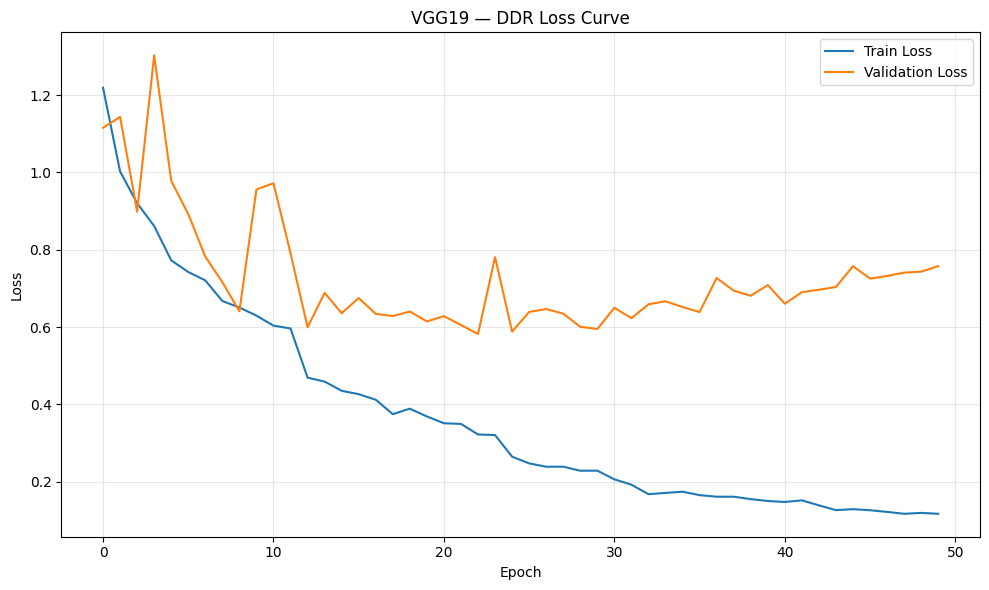

In [33]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "VGG19 — DDR Loss Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

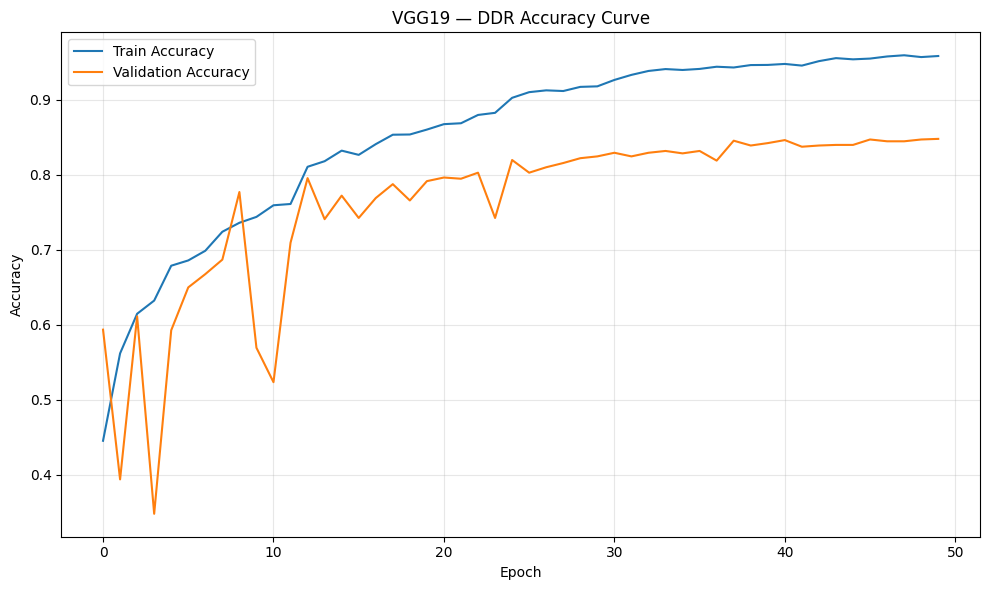

In [34]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "VGG19 — DDR Accuracy Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

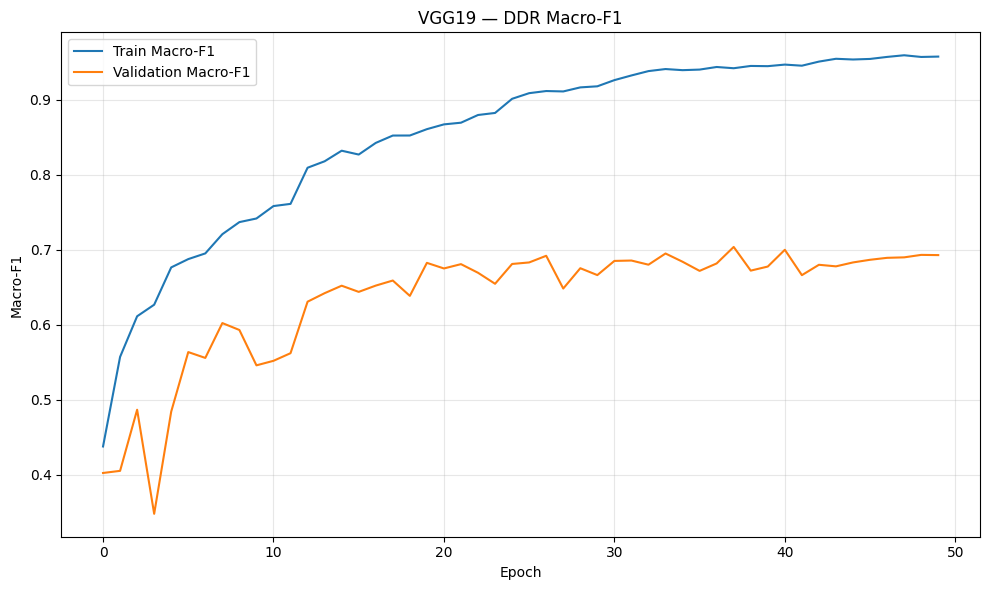

In [35]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history["train_f1_macro"],
    label="Train Macro-F1"
)

plt.plot(
    history["val_f1_macro"],
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")

plt.title(
    "VGG19 — DDR Macro-F1"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "macro_f1_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

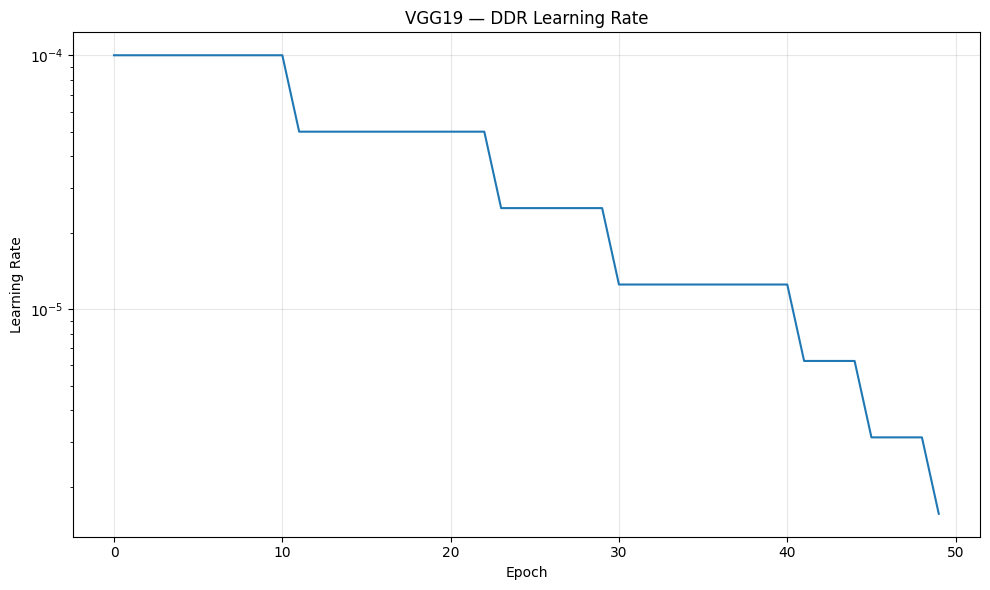

In [36]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history["learning_rate"]
)

plt.xlabel("Epoch")

plt.ylabel(
    "Learning Rate"
)

plt.title(
    "VGG19 — DDR Learning Rate"
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "learning_rate_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
print("=" * 80)
print("LOADING BEST VGG19 CHECKPOINT")
print("=" * 80)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation Macro-F1:",
    checkpoint["best_val_f1"]
)

LOADING BEST VGG19 CHECKPOINT
Best epoch: 38
Best validation Macro-F1: 0.7039162703424713


In [38]:
(
    test_loss,
    test_metrics,
    y_true,
    y_pred,
    y_probs
) = evaluate_model(
    model,
    test_loader,
    criterion,
    DEVICE
)

print("=" * 80)
print("VGG19 — DDR TEST RESULTS")
print("=" * 80)

print(
    f"Test Loss         : "
    f"{test_loss:.4f}"
)

print(
    f"Accuracy           : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Macro Precision    : "
    f"{test_metrics['precision_macro']:.4f}"
)

print(
    f"Macro Recall       : "
    f"{test_metrics['recall_macro']:.4f}"
)

print(
    f"Macro F1           : "
    f"{test_metrics['f1_macro']:.4f}"
)

print(
    f"Weighted Precision : "
    f"{test_metrics['precision_weighted']:.4f}"
)

print(
    f"Weighted Recall    : "
    f"{test_metrics['recall_weighted']:.4f}"
)

print(
    f"Weighted F1       : "
    f"{test_metrics['f1_weighted']:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{test_metrics['balanced_accuracy']:.4f}"
)

print(
    f"Cohen Kappa       : "
    f"{test_metrics['kappa']:.4f}"
)

print(
    f"MCC               : "
    f"{test_metrics['mcc']:.4f}"
)

VGG19 — DDR TEST RESULTS
Test Loss         : 0.7691
Accuracy           : 0.8335
Macro Precision    : 0.6503
Macro Recall       : 0.6120
Macro F1           : 0.6283
Weighted Precision : 0.8230
Weighted Recall    : 0.8335
Weighted F1       : 0.8272
Balanced Accuracy : 0.6120
Cohen Kappa       : 0.7241
MCC               : 0.7249


In [39]:
report = classification_report(

    y_true,

    y_pred,

    target_names=
        train_dataset.classes,

    digits=4,

    zero_division=0
)

print(report)

with open(
    OUTPUT_DIR /
    "classification_report.txt",
    "w"
) as f:

    f.write(report)

                    precision    recall  f1-score   support

           0_No_DR     0.8785    0.9254    0.9013       617
            1_Mild     0.3023    0.2063    0.2453        63
        2_Moderate     0.8304    0.8304    0.8304       448
          3_Severe     0.3500    0.3043    0.3256        23
4_Proliferative_DR     0.8902    0.7935    0.8391        92

          accuracy                         0.8335      1243
         macro avg     0.6503    0.6120    0.6283      1243
      weighted avg     0.8230    0.8335    0.8272      1243



In [40]:
report_dict = classification_report(

    y_true,

    y_pred,

    target_names=
        train_dataset.classes,

    output_dict=True,

    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

display(
    report_df
)

report_df.to_csv(
    OUTPUT_DIR /
    "classification_report.csv"
)

,precision,recall,f1-score,support
0_No_DR,0.878462,0.925446,0.901342,617.000000
1_Mild,0.302326,0.206349,0.245283,63.000000
2_Moderate,0.830357,0.830357,0.830357,448.000000
3_Severe,0.350000,0.304348,0.325581,23.000000
4_Proliferative_DR,0.890244,0.793478,0.839080,92.000000
accuracy,0.833467,0.833467,0.833467,0.833467
macro avg,0.650278,0.611996,0.628329,1243.000000
weighted avg,0.823017,0.833467,0.827244,1243.000000


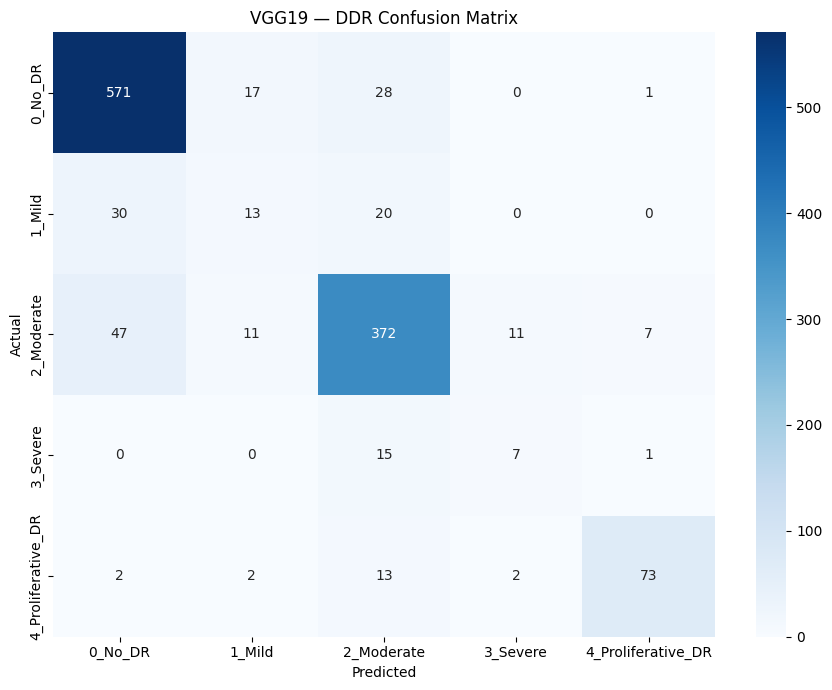

In [41]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=
        train_dataset.classes,

    yticklabels=
        train_dataset.classes
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "VGG19 — DDR Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

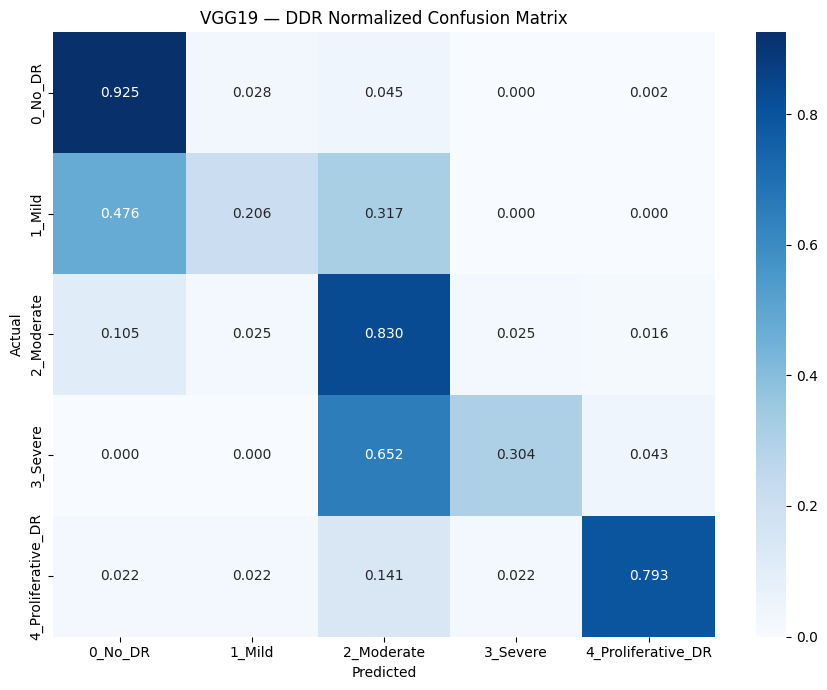

In [42]:
cm_normalized = (
    cm.astype(float)
    /
    cm.sum(
        axis=1,
        keepdims=True
    )
)

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(

    cm_normalized,

    annot=True,

    fmt=".3f",

    cmap="Blues",

    xticklabels=
        train_dataset.classes,

    yticklabels=
        train_dataset.classes
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "VGG19 — DDR Normalized Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "normalized_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
specificity = []

sensitivity = []

for i in range(
    NUM_CLASSES
):

    TP = cm[i, i]

    FN = (
        cm[i, :].sum()
        - TP
    )

    FP = (
        cm[:, i].sum()
        - TP
    )

    TN = (
        cm.sum()
        - TP
        - FN
        - FP
    )

    sens = (
        TP /
        (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    spec = (
        TN /
        (TN + FP)
        if (TN + FP) > 0
        else 0
    )

    sensitivity.append(
        sens
    )

    specificity.append(
        spec
    )


sens_spec_df = pd.DataFrame({

    "Class":
        train_dataset.classes,

    "Sensitivity":
        sensitivity,

    "Specificity":
        specificity

})

display(
    sens_spec_df
)

sens_spec_df.to_csv(
    OUTPUT_DIR /
    "sensitivity_specificity.csv",
    index=False
)

,Class,Sensitivity,Specificity
0,0_No_DR,0.925446,0.873802
1,1_Mild,0.206349,0.974576
2,2_Moderate,0.830357,0.904403
3,3_Severe,0.304348,0.989344
4,4_Proliferative_DR,0.793478,0.992181


In [44]:
y_true_bin = label_binarize(

    y_true,

    classes=np.arange(
        NUM_CLASSES
    )
)

roc_auc_macro = roc_auc_score(

    y_true_bin,

    y_probs,

    average="macro",

    multi_class="ovr"
)

roc_auc_weighted = roc_auc_score(

    y_true_bin,

    y_probs,

    average="weighted",

    multi_class="ovr"
)

print(
    f"Macro ROC-AUC    : "
    f"{roc_auc_macro:.4f}"
)

print(
    f"Weighted ROC-AUC : "
    f"{roc_auc_weighted:.4f}"
)

Macro ROC-AUC    : 0.9063
Weighted ROC-AUC : 0.9454


In [45]:
roc_auc_per_class = {}

for i, class_name in enumerate(
    train_dataset.classes
):

    roc_auc_per_class[
        class_name
    ] = roc_auc_score(

        y_true_bin[:, i],

        y_probs[:, i]
    )


roc_auc_df = pd.DataFrame({

    "Class":
        list(
            roc_auc_per_class.keys()
        ),

    "ROC_AUC":
        list(
            roc_auc_per_class.values()
        )

})

display(
    roc_auc_df
)

roc_auc_df.to_csv(
    OUTPUT_DIR /
    "roc_auc_per_class.csv",
    index=False
)

,Class,ROC_AUC
0,0_No_DR,0.965553
1,1_Mild,0.779244
2,2_Moderate,0.937284
3,3_Severe,0.865467
4,4_Proliferative_DR,0.984201


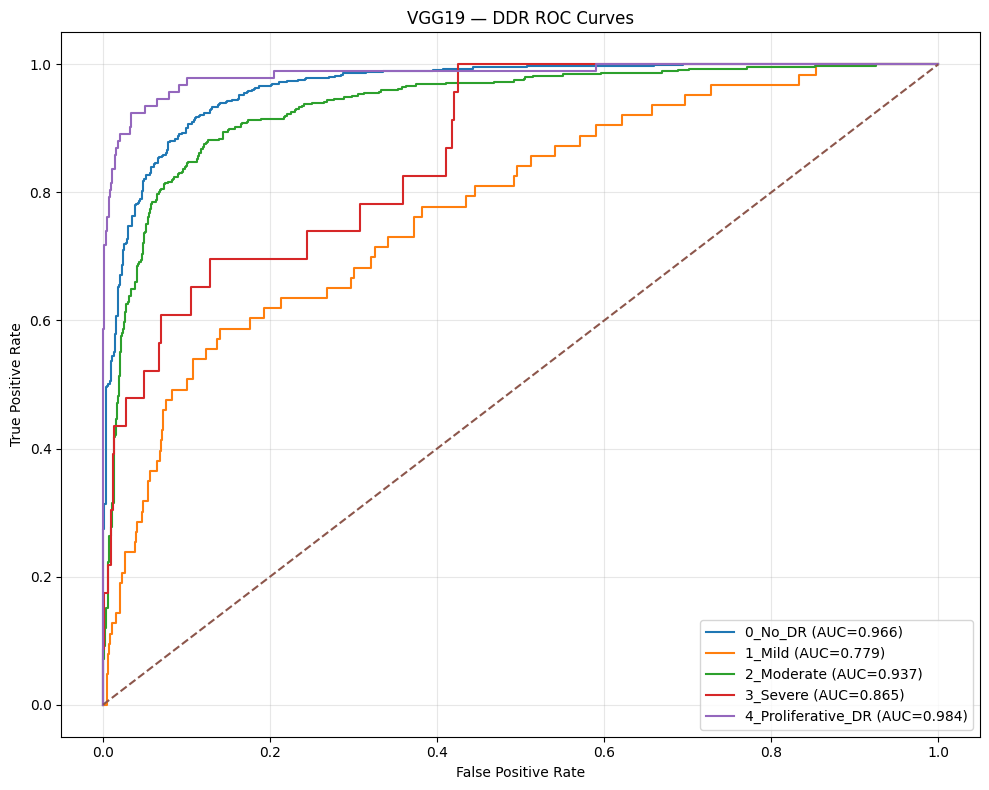

In [46]:
plt.figure(
    figsize=(10, 8)
)

for i, class_name in enumerate(
    train_dataset.classes
):

    fpr, tpr, _ = roc_curve(

        y_true_bin[:, i],

        y_probs[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(

        fpr,

        tpr,

        label=
        f"{class_name} "
        f"(AUC={roc_auc:.3f})"
    )


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "VGG19 — DDR ROC Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
pr_auc_per_class = {}

for i, class_name in enumerate(
    train_dataset.classes
):

    precision, recall, _ = (
        precision_recall_curve(

            y_true_bin[:, i],

            y_probs[:, i]
        )
    )

    pr_auc = auc(
        recall,
        precision
    )

    pr_auc_per_class[
        class_name
    ] = pr_auc


pr_auc_macro = np.mean(
    list(
        pr_auc_per_class.values()
    )
)

print(
    f"Macro PR-AUC: "
    f"{pr_auc_macro:.4f}"
)


pr_auc_df = pd.DataFrame({

    "Class":
        list(
            pr_auc_per_class.keys()
        ),

    "PR_AUC":
        list(
            pr_auc_per_class.values()
        )

})

display(
    pr_auc_df
)

Macro PR-AUC: 0.6536


,Class,PR_AUC
0,0_No_DR,0.964304
1,1_Mild,0.193427
2,2_Moderate,0.893718
3,3_Severe,0.296413
4,4_Proliferative_DR,0.919967


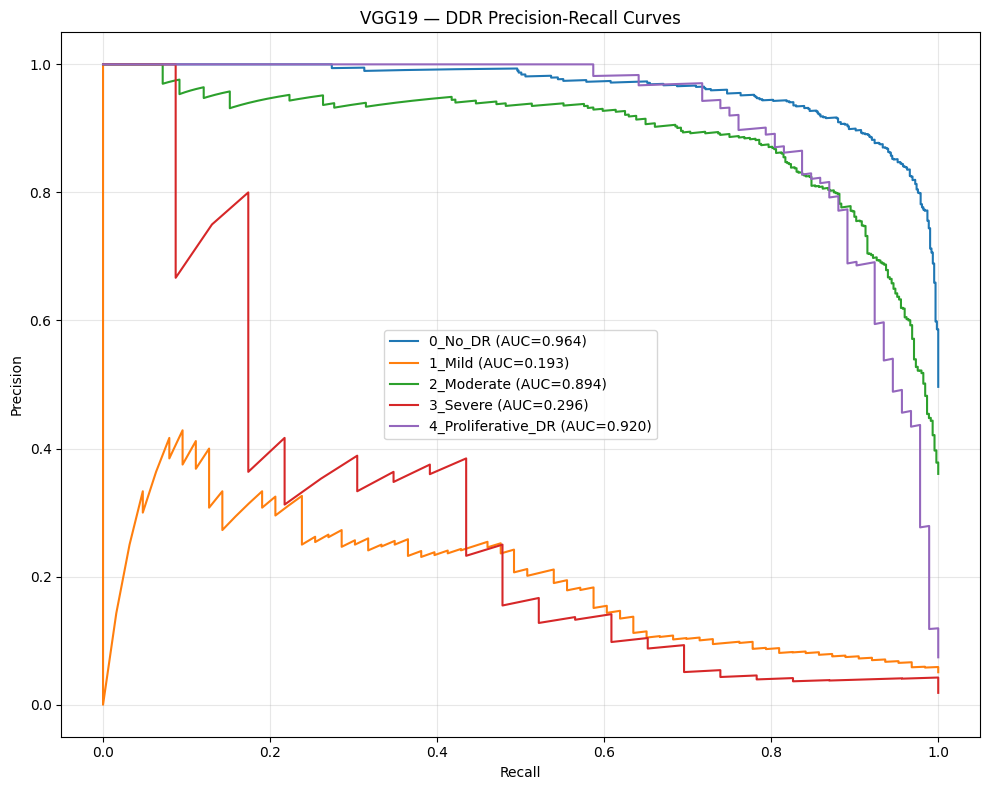

In [48]:
plt.figure(
    figsize=(10, 8)
)

for i, class_name in enumerate(
    train_dataset.classes
):

    precision, recall, _ = (
        precision_recall_curve(

            y_true_bin[:, i],

            y_probs[:, i]
        )
    )

    pr_auc = auc(
        recall,
        precision
    )

    plt.plot(

        recall,

        precision,

        label=
        f"{class_name} "
        f"(AUC={pr_auc:.3f})"
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "VGG19 — DDR Precision-Recall Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "pr_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
test_log_loss = log_loss(

    y_true,

    y_probs,

    labels=np.arange(
        NUM_CLASSES
    )
)

print(
    f"Test Log Loss: "
    f"{test_log_loss:.6f}"
)

Test Log Loss: 0.767553


In [50]:
brier_scores = {}

for i, class_name in enumerate(
    train_dataset.classes
):

    brier_scores[
        class_name
    ] = brier_score_loss(

        y_true_bin[:, i],

        y_probs[:, i]
    )


brier_df = pd.DataFrame({

    "Class":
        list(
            brier_scores.keys()
        ),

    "Brier_Score":
        list(
            brier_scores.values()
        )

})

display(
    brier_df
)

mean_brier = np.mean(
    list(
        brier_scores.values()
    )
)

print(
    "Mean Brier Score:",
    mean_brier
)

,Class,Brier_Score
0,0_No_DR,0.074600
1,1_Mild,0.054378
2,2_Moderate,0.093391
3,3_Severe,0.020568
4,4_Proliferative_DR,0.019737


Mean Brier Score: 0.05253463148968831


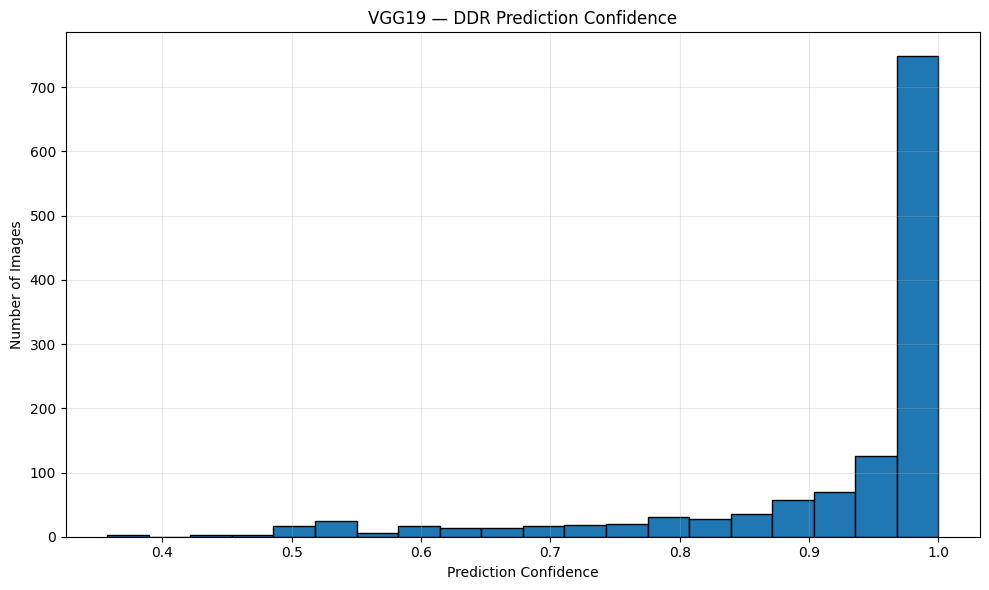

Mean confidence: 0.9223906
Median confidence: 0.9818625


In [51]:
confidence = np.max(
    y_probs,
    axis=1
)

plt.figure(
    figsize=(10, 6)
)

plt.hist(

    confidence,

    bins=20,

    edgecolor="black"
)

plt.xlabel(
    "Prediction Confidence"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "VGG19 — DDR Prediction Confidence"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Mean confidence:",
    confidence.mean()
)

print(
    "Median confidence:",
    np.median(confidence)
)

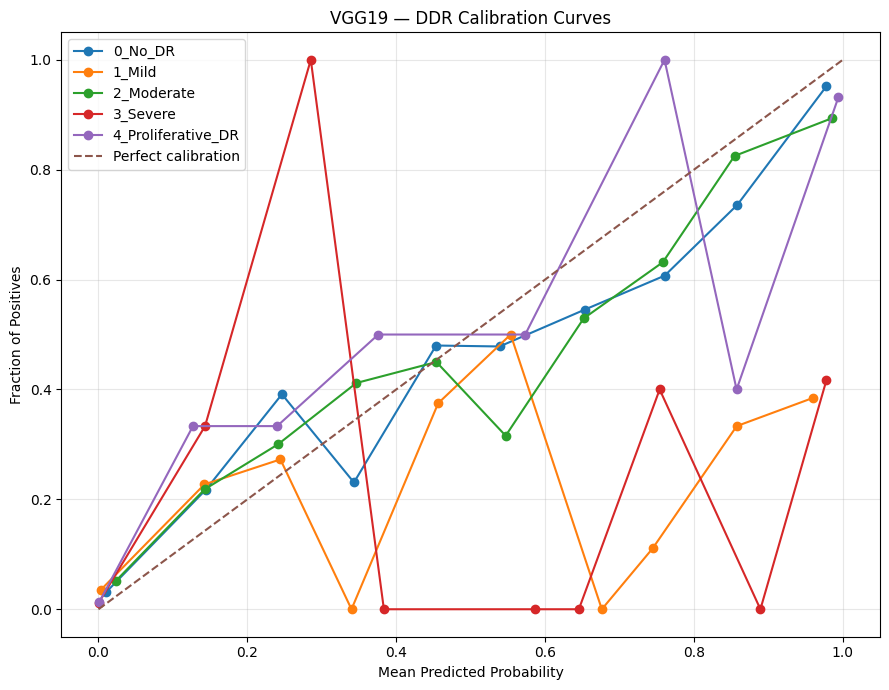

In [52]:
plt.figure(
    figsize=(9, 7)
)

for i, class_name in enumerate(
    train_dataset.classes
):

    prob_true, prob_pred = (
        calibration_curve(

            y_true_bin[:, i],

            y_probs[:, i],

            n_bins=10,

            strategy="uniform"
        )
    )

    plt.plot(

        prob_pred,

        prob_true,

        marker="o",

        label=class_name
    )


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    label="Perfect calibration"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Fraction of Positives"
)

plt.title(
    "VGG19 — DDR Calibration Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "calibration_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
prediction_df = pd.DataFrame({

    "true_label":
        y_true,

    "predicted_label":
        y_pred,

    "true_class": [

        train_dataset.classes[
            x
        ]

        for x in y_true
    ],

    "predicted_class": [

        train_dataset.classes[
            x
        ]

        for x in y_pred
    ],

    "confidence":
        confidence

})


for i, class_name in enumerate(
    train_dataset.classes
):

    prediction_df[
        f"prob_{class_name}"
    ] = y_probs[:, i]


display(
    prediction_df.head()
)

prediction_df.to_csv(

    OUTPUT_DIR /
    "test_predictions.csv",

    index=False
)

,true_label,predicted_label,true_class,predicted_class,confidence,prob_0_No_DR,prob_1_Mild,prob_2_Moderate,prob_3_Severe,prob_4_Proliferative_DR
0,0,0,0_No_DR,0_No_DR,0.959161,0.959161,3.092871e-04,0.040529,5.394596e-08,9.411211e-07
1,0,0,0_No_DR,0_No_DR,0.983157,0.983157,4.940286e-08,0.016843,1.776846e-13,3.093043e-09
2,0,0,0_No_DR,0_No_DR,0.424624,0.424624,3.824399e-01,0.192621,7.422185e-05,2.408109e-04
3,0,0,0_No_DR,0_No_DR,0.926893,0.926893,3.306162e-02,0.040039,7.708144e-07,5.864497e-06
4,0,0,0_No_DR,0_No_DR,0.639310,0.639310,2.189500e-04,0.360415,3.144045e-08,5.600996e-05


In [54]:
test_paths = [
    path
    for path, _ in test_dataset.samples
]

misclassified_indices = np.where(

    y_true != y_pred

)[0]

print(
    "Total test images:",
    len(y_true)
)

print(
    "Misclassified images:",
    len(misclassified_indices)
)

print(
    "Correct predictions:",
    len(y_true) -
    len(misclassified_indices)
)

print(
    "Error rate:",
    len(misclassified_indices)
    /
    len(y_true)
)

Total test images: 1243
Misclassified images: 207
Correct predictions: 1036
Error rate: 0.166532582461786


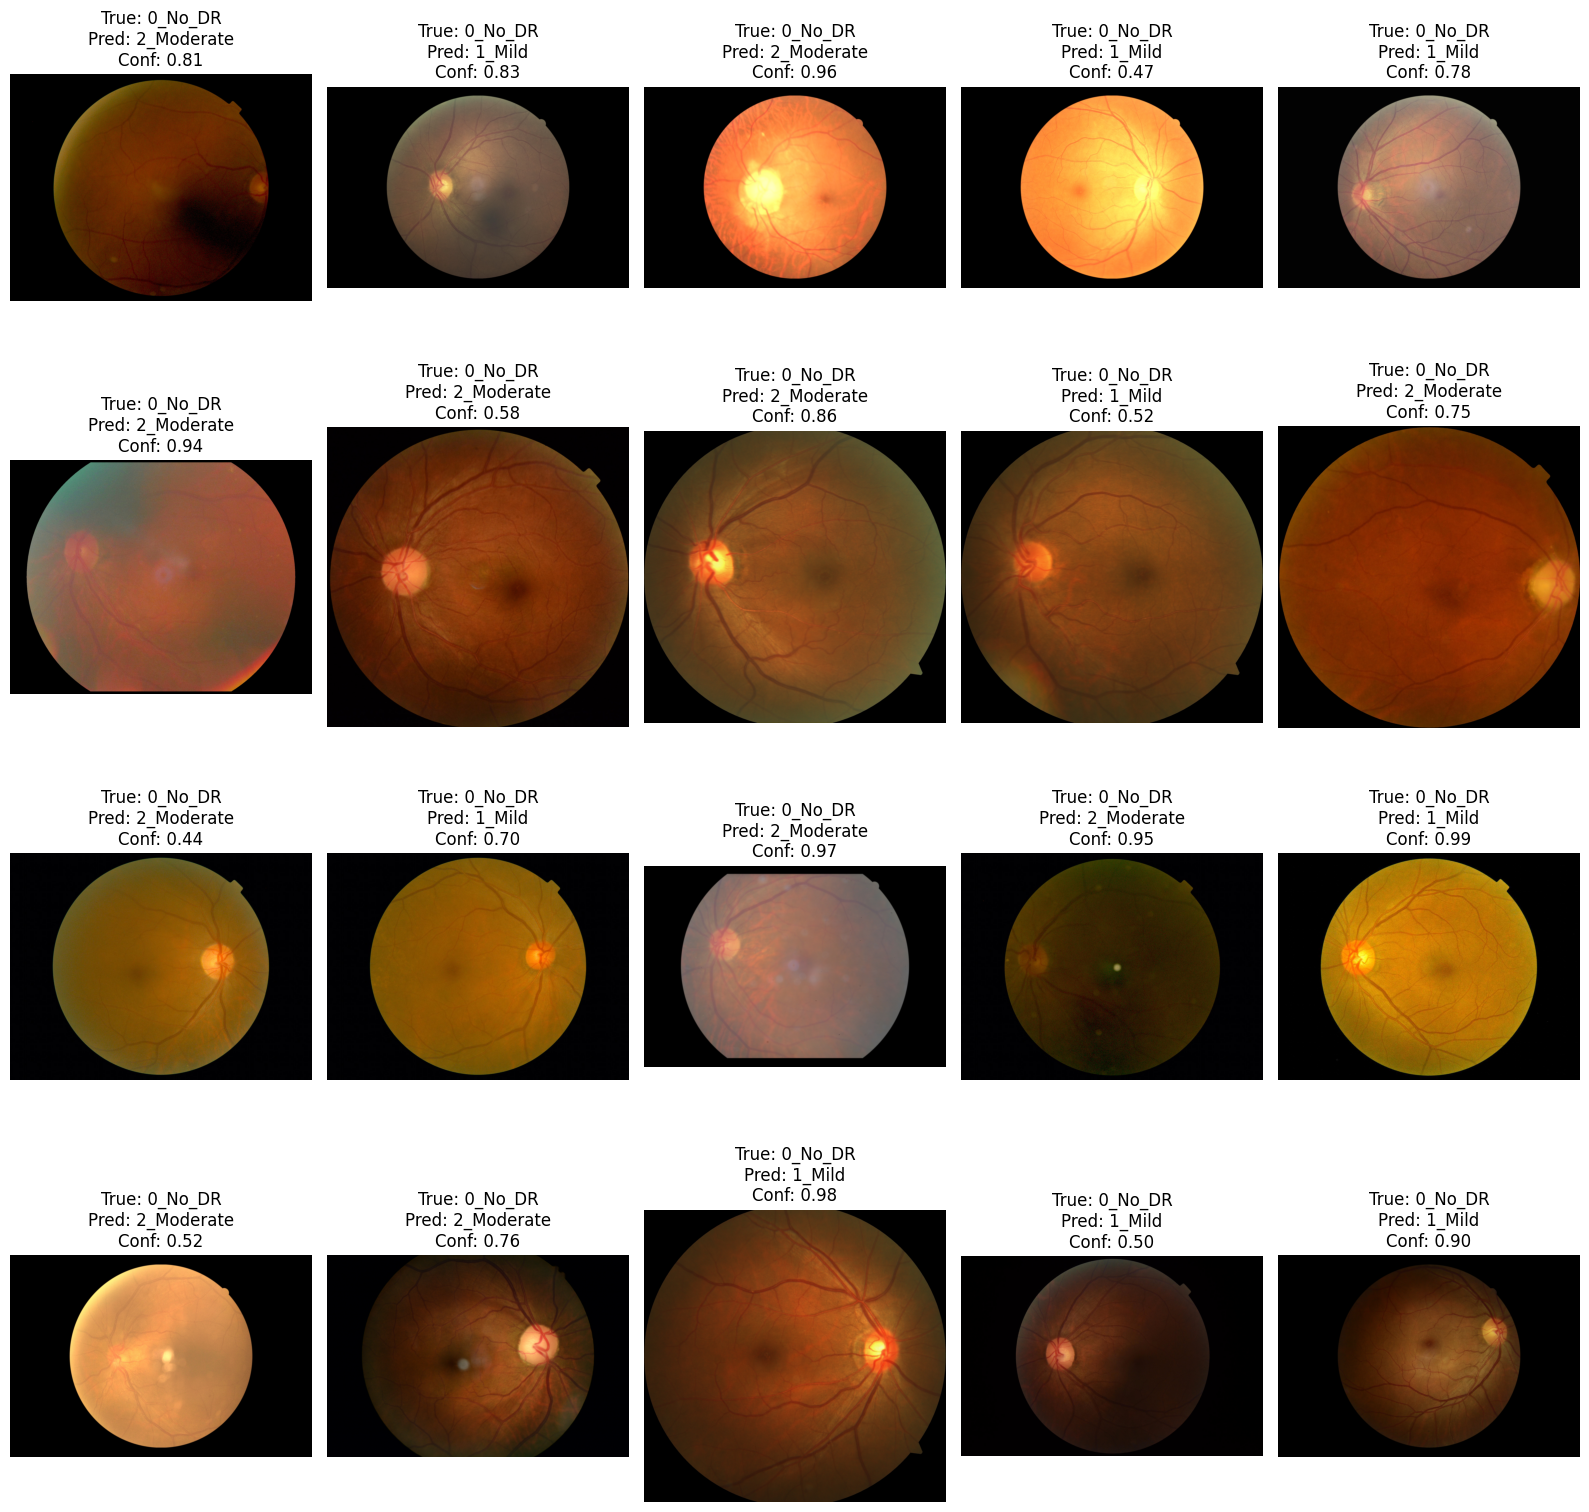

In [55]:
n_show = min(
    20,
    len(misclassified_indices)
)

plt.figure(
    figsize=(16, 16)
)

for plot_idx, sample_idx in enumerate(

    misclassified_indices[
        :n_show
    ]

):

    image_path = (
        test_paths[
            sample_idx
        ]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    plt.subplot(
        4,
        5,
        plot_idx + 1
    )

    plt.imshow(
        image
    )

    plt.title(

        f"True: "
        f"{train_dataset.classes[y_true[sample_idx]]}\n"

        f"Pred: "
        f"{train_dataset.classes[y_pred[sample_idx]]}\n"

        f"Conf: "
        f"{confidence[sample_idx]:.2f}"
    )

    plt.axis(
        "off"
    )


plt.tight_layout()

plt.savefig(

    OUTPUT_DIR /
    "misclassified_images.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()

In [56]:
per_class_precision = precision_score(

    y_true,

    y_pred,

    average=None,

    zero_division=0
)

per_class_recall = recall_score(

    y_true,

    y_pred,

    average=None,

    zero_division=0
)

per_class_f1 = f1_score(

    y_true,

    y_pred,

    average=None,

    zero_division=0
)


per_class_df = pd.DataFrame({

    "Class":
        train_dataset.classes,

    "Precision":
        per_class_precision,

    "Recall":
        per_class_recall,

    "F1":
        per_class_f1,

    "Sensitivity":
        sensitivity,

    "Specificity":
        specificity,

    "ROC_AUC": [

        roc_auc_per_class[c]

        for c in
        train_dataset.classes
    ],

    "PR_AUC": [

        pr_auc_per_class[c]

        for c in
        train_dataset.classes
    ]

})


display(
    per_class_df
)

per_class_df.to_csv(

    OUTPUT_DIR /
    "per_class_metrics.csv",

    index=False
)

,Class,Precision,Recall,F1,Sensitivity,Specificity,ROC_AUC,PR_AUC
0,0_No_DR,0.878462,0.925446,0.901342,0.925446,0.873802,0.965553,0.964304
1,1_Mild,0.302326,0.206349,0.245283,0.206349,0.974576,0.779244,0.193427
2,2_Moderate,0.830357,0.830357,0.830357,0.830357,0.904403,0.937284,0.893718
3,3_Severe,0.350000,0.304348,0.325581,0.304348,0.989344,0.865467,0.296413
4,4_Proliferative_DR,0.890244,0.793478,0.839080,0.793478,0.992181,0.984201,0.919967


In [57]:
overall_metrics = {

    "Test Loss":
        test_loss,

    "Accuracy":
        test_metrics[
            "accuracy"
        ],

    "Macro Precision":
        test_metrics[
            "precision_macro"
        ],

    "Macro Recall":
        test_metrics[
            "recall_macro"
        ],

    "Macro F1":
        test_metrics[
            "f1_macro"
        ],

    "Weighted Precision":
        test_metrics[
            "precision_weighted"
        ],

    "Weighted Recall":
        test_metrics[
            "recall_weighted"
        ],

    "Weighted F1":
        test_metrics[
            "f1_weighted"
        ],

    "Balanced Accuracy":
        test_metrics[
            "balanced_accuracy"
        ],

    "Cohen Kappa":
        test_metrics[
            "kappa"
        ],

    "MCC":
        test_metrics[
            "mcc"
        ],

    "Macro ROC-AUC":
        roc_auc_macro,

    "Weighted ROC-AUC":
        roc_auc_weighted,

    "Macro PR-AUC":
        pr_auc_macro,

    "Log Loss":
        test_log_loss,

    "Mean Brier Score":
        mean_brier,

    "Mean Confidence":
        confidence.mean()

}


overall_df = pd.DataFrame(

    list(
        overall_metrics.items()
    ),

    columns=[
        "Metric",
        "Value"
    ]
)

display(
    overall_df
)

overall_df.to_csv(

    OUTPUT_DIR /
    "overall_metrics.csv",

    index=False
)

,Metric,Value
0,Test Loss,0.769144
1,Accuracy,0.833467
2,Macro Precision,0.650278
3,Macro Recall,0.611996
4,Macro F1,0.628329
5,Weighted Precision,0.823017
6,Weighted Recall,0.833467
7,Weighted F1,0.827244
8,Balanced Accuracy,0.611996
9,Cohen Kappa,0.724098


In [58]:
def bootstrap_metric(

    y_true,

    y_pred,

    metric_function,

    n_bootstrap=2000,

    seed=42

):

    rng = np.random.default_rng(
        seed
    )

    n = len(y_true)

    values = []

    for _ in range(
        n_bootstrap
    ):

        indices = rng.integers(

            0,

            n,

            size=n
        )

        try:

            value = metric_function(

                y_true[indices],

                y_pred[indices]
            )

            values.append(
                value
            )

        except Exception:

            continue


    values = np.array(
        values
    )

    lower = np.percentile(
        values,
        2.5
    )

    upper = np.percentile(
        values,
        97.5
    )

    return (
        values.mean(),
        lower,
        upper
    )

In [59]:
accuracy_mean, accuracy_low, accuracy_high = (

    bootstrap_metric(

        y_true,

        y_pred,

        accuracy_score
    )
)

print(

    f"Accuracy: "
    f"{accuracy_mean:.4f} "

    f"(95% CI "
    f"{accuracy_low:.4f}–"
    f"{accuracy_high:.4f})"
)

Accuracy: 0.8334 (95% CI 0.8134–0.8544)


In [60]:
f1_mean, f1_low, f1_high = (

    bootstrap_metric(

        y_true,

        y_pred,

        lambda yt, yp:

        f1_score(

            yt,

            yp,

            average="macro",

            zero_division=0
        )
    )
)

print(

    f"Macro-F1: "
    f"{f1_mean:.4f} "

    f"(95% CI "
    f"{f1_low:.4f}–"
    f"{f1_high:.4f})"
)

Macro-F1: 0.6263 (95% CI 0.5787–0.6742)


In [61]:
ba_mean, ba_low, ba_high = (

    bootstrap_metric(

        y_true,

        y_pred,

        balanced_accuracy_score
    )
)

print(

    f"Balanced Accuracy: "
    f"{ba_mean:.4f} "

    f"(95% CI "
    f"{ba_low:.4f}–"
    f"{ba_high:.4f})"
)

Balanced Accuracy: 0.6116 (95% CI 0.5645–0.6592)


In [62]:
bootstrap_df = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Macro-F1",

        "Balanced Accuracy"

    ],

    "Mean": [

        accuracy_mean,

        f1_mean,

        ba_mean
    ],

    "CI_Lower_95": [

        accuracy_low,

        f1_low,

        ba_low
    ],

    "CI_Upper_95": [

        accuracy_high,

        f1_high,

        ba_high
    ]

})


display(
    bootstrap_df
)

bootstrap_df.to_csv(

    OUTPUT_DIR /
    "bootstrap_95CI.csv",

    index=False
)

,Metric,Mean,CI_Lower_95,CI_Upper_95
0,Accuracy,0.833386,0.813355,0.854385
1,Macro-F1,0.626310,0.578663,0.674219
2,Balanced Accuracy,0.611627,0.564465,0.659199


In [63]:
config = {

    "model":
        "VGG19",

    "dataset":
        "DDR",

    "dataset_total":
        total_images,

    "train_images":
        train_total,

    "validation_images":
        val_total,

    "test_images":
        test_total,

    "image_size":
        IMAGE_SIZE,

    "batch_size":
        BATCH_SIZE,

    "epochs_requested":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "optimizer":
        "AdamW",

    "scheduler":
        "ReduceLROnPlateau",

    "scheduler_factor":
        LR_FACTOR,

    "scheduler_patience":
        LR_PATIENCE,

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "sampling":
        "WeightedRandomSampler — training only",

    "pretrained":
        "ImageNet",

    "seed":
        SEED,

    "num_classes":
        NUM_CLASSES,

    "class_names":
        train_dataset.classes,

    "device":
        str(DEVICE),

    "best_epoch":
        int(
            checkpoint["epoch"]
        ),

    "best_validation_macro_f1":
        float(
            best_val_f1
        ),

    "test_metrics": {

        k: float(v)

        for k, v
        in test_metrics.items()

    },

    "roc_auc_macro":
        float(
            roc_auc_macro
        ),

    "roc_auc_weighted":
        float(
            roc_auc_weighted
        ),

    "pr_auc_macro":
        float(
            pr_auc_macro
        ),

    "log_loss":
        float(
            test_log_loss
        ),

    "mean_brier_score":
        float(
            mean_brier
        )

}


with open(

    OUTPUT_DIR /
    "experiment_config.json",

    "w"

) as f:

    json.dump(

        config,

        f,

        indent=4
    )


print(
    json.dumps(
        config,
        indent=4
    )
)

{
    "model": "VGG19",
    "dataset": "DDR",
    "dataset_total": 12422,
    "train_images": 9937,
    "validation_images": 1242,
    "test_images": 1243,
    "image_size": 224,
    "batch_size": 16,
    "epochs_requested": 50,
    "learning_rate": 0.0001,
    "weight_decay": 0.0005,
    "optimizer": "AdamW",
    "scheduler": "ReduceLROnPlateau",
    "scheduler_factor": 0.5,
    "scheduler_patience": 3,
    "early_stopping_patience": 100,
    "sampling": "WeightedRandomSampler \u2014 training only",
    "pretrained": "ImageNet",
    "seed": 42,
    "num_classes": 5,
    "class_names": [
        "0_No_DR",
        "1_Mild",
        "2_Moderate",
        "3_Severe",
        "4_Proliferative_DR"
    ],
    "device": "cuda",
    "best_epoch": 38,
    "best_validation_macro_f1": 0.7039162703424713,
    "test_metrics": {
        "accuracy": 0.833467417538214,
        "precision_macro": 0.6502776330306109,
        "recall_macro": 0.6119956282374364,
        "f1_macro": 0.6283287538029002,
  

In [64]:
FINAL_MODEL_PATH = (

    OUTPUT_DIR /
    "VGG19_DDR_final.pth"

)

torch.save(

    {

        "model_state_dict":
            model.state_dict(),

        "class_names":
            train_dataset.classes,

        "config":
            config,

        "test_metrics":
            test_metrics

    },

    FINAL_MODEL_PATH
)

print(
    "Final model saved:"
)

print(
    FINAL_MODEL_PATH
)

Final model saved:
/kaggle/working/vgg19_ddr_results/VGG19_DDR_final.pth


In [65]:
summary = {

    "Model":
        "VGG19",

    "Dataset":
        "DDR",

    "Train Images":
        train_total,

    "Validation Images":
        val_total,

    "Test Images":
        test_total,

    "Best Epoch":
        checkpoint["epoch"],

    "Test Accuracy":
        test_metrics[
            "accuracy"
        ],

    "Macro Precision":
        test_metrics[
            "precision_macro"
        ],

    "Macro Recall":
        test_metrics[
            "recall_macro"
        ],

    "Macro F1":
        test_metrics[
            "f1_macro"
        ],

    "Weighted F1":
        test_metrics[
            "f1_weighted"
        ],

    "Balanced Accuracy":
        test_metrics[
            "balanced_accuracy"
        ],

    "ROC-AUC":
        roc_auc_macro,

    "PR-AUC":
        pr_auc_macro,

    "Cohen Kappa":
        test_metrics[
            "kappa"
        ],

    "MCC":
        test_metrics[
            "mcc"
        ],

    "Log Loss":
        test_log_loss

}


summary_df = pd.DataFrame(
    [summary]
)

display(
    summary_df
)

summary_df.to_csv(

    OUTPUT_DIR /
    "FINAL_RESULTS.csv",

    index=False
)

,Model,Dataset,Train Images,Validation Images,Test Images,Best Epoch,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Balanced Accuracy,ROC-AUC,PR-AUC,Cohen Kappa,MCC,Log Loss
0,VGG19,DDR,9937,1242,1243,38,0.833467,0.650278,0.611996,0.628329,0.827244,0.611996,0.90635,0.653566,0.724098,0.724868,0.767553


In [66]:
print("=" * 80)
print("VGG19 DDR RESULT FILES")
print("=" * 80)

for file in sorted(
    OUTPUT_DIR.iterdir()
):

    if file.is_file():

        size_mb = (

            file.stat().st_size
            /
            (1024 ** 2)

        )

        print(

            f"{file.name:45s}"
            f"{size_mb:10.2f} MB"
        )

VGG19 DDR RESULT FILES
FINAL_RESULTS.csv                                  0.00 MB
VGG19_DDR_final.pth                              532.51 MB
accuracy_curve.png                                 0.18 MB
best_vgg19_ddr.pth                              1597.54 MB
bootstrap_95CI.csv                                 0.00 MB
calibration_curves.png                             0.43 MB
classification_report.csv                          0.00 MB
classification_report.txt                          0.00 MB
confidence_distribution.png                        0.09 MB
confusion_matrix.png                               0.14 MB
experiment_config.json                             0.00 MB
learning_rate_curve.png                            0.08 MB
loss_curve.png                                     0.18 MB
macro_f1_curve.png                                 0.16 MB
misclassified_images.png                          11.01 MB
normalized_confusion_matrix.png                    0.18 MB
overall_metrics.csv              

In [67]:
RESULTS_ZIP = Path(

    "/kaggle/working/"
    "VGG19_DDR_results.zip"

)

if RESULTS_ZIP.exists():

    RESULTS_ZIP.unlink()


with zipfile.ZipFile(

    RESULTS_ZIP,

    "w",

    zipfile.ZIP_DEFLATED

) as z:

    for file in OUTPUT_DIR.rglob("*"):

        if file.is_file():

            z.write(

                file,

                file.relative_to(
                    OUTPUT_DIR
                )
            )


print(
    "Results ZIP:"
)

print(
    RESULTS_ZIP
)

print(

    f"Size: "
    f"{RESULTS_ZIP.stat().st_size / (1024**2):.2f} MB"
)

Results ZIP:
/kaggle/working/VGG19_DDR_results.zip
Size: 1729.54 MB


In [68]:
print("=" * 90)
print("FINAL VGG19 — DDR RESULTS")
print("=" * 90)

print(
    f"Accuracy          : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Macro Precision   : "
    f"{test_metrics['precision_macro']:.4f}"
)

print(
    f"Macro Recall      : "
    f"{test_metrics['recall_macro']:.4f}"
)

print(
    f"Macro F1          : "
    f"{test_metrics['f1_macro']:.4f}"
)

print(
    f"Weighted F1       : "
    f"{test_metrics['f1_weighted']:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{test_metrics['balanced_accuracy']:.4f}"
)

print(
    f"ROC-AUC           : "
    f"{roc_auc_macro:.4f}"
)

print(
    f"PR-AUC            : "
    f"{pr_auc_macro:.4f}"
)

print(
    f"Cohen Kappa       : "
    f"{test_metrics['kappa']:.4f}"
)

print(
    f"MCC               : "
    f"{test_metrics['mcc']:.4f}"
)

print(
    f"Log Loss          : "
    f"{test_log_loss:.4f}"
)

print("=" * 90)
print("VGG19 DDR TRAINING COMPLETE")
print("=" * 90)

FINAL VGG19 — DDR RESULTS
Accuracy          : 0.8335
Macro Precision   : 0.6503
Macro Recall      : 0.6120
Macro F1          : 0.6283
Weighted F1       : 0.8272
Balanced Accuracy : 0.6120
ROC-AUC           : 0.9063
PR-AUC            : 0.6536
Cohen Kappa       : 0.7241
MCC               : 0.7249
Log Loss          : 0.7676
VGG19 DDR TRAINING COMPLETE
